Epoch 1/50


/var/folders/55/7xrddlh52154tfs5y0cd8s_40000gn/T/ipykernel_21923/706217155.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trends['date'] = pd.to_datetime(trends['date'], errors='coerce')


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2169 - val_loss: 0.2050 - learning_rate: 0.0010
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1474 - val_loss: 0.0778 - learning_rate: 0.0010
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0726 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0482 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0440 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0391 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0388 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0397 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0378 - val_loss: 0.0275 - learning_rate: 0.0010
Epoch 10/50
 1/11 ━━━━━━━━━━━━━━━━━━━━ 

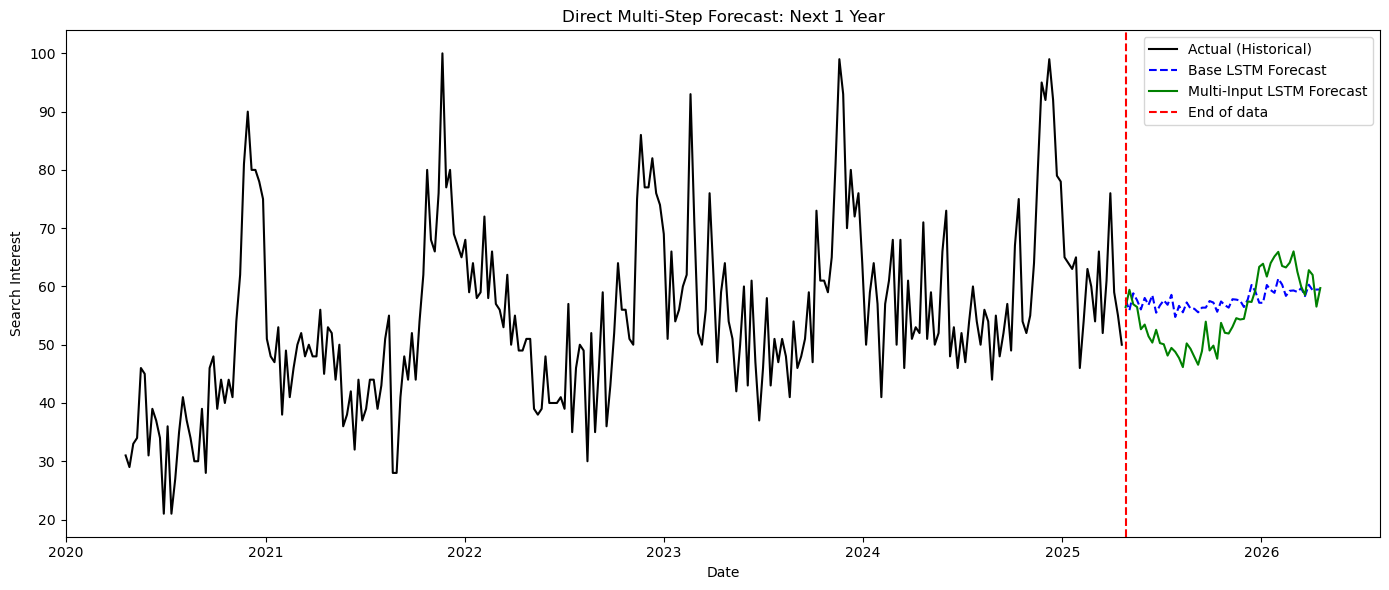

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Base LSTM Test RMSE:       12.8994
Multi‐Input LSTM Test RMSE: 12.4750
✅ Test‐split forecast (first sample) saved to 'test_split_forecast_sample1.csv'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


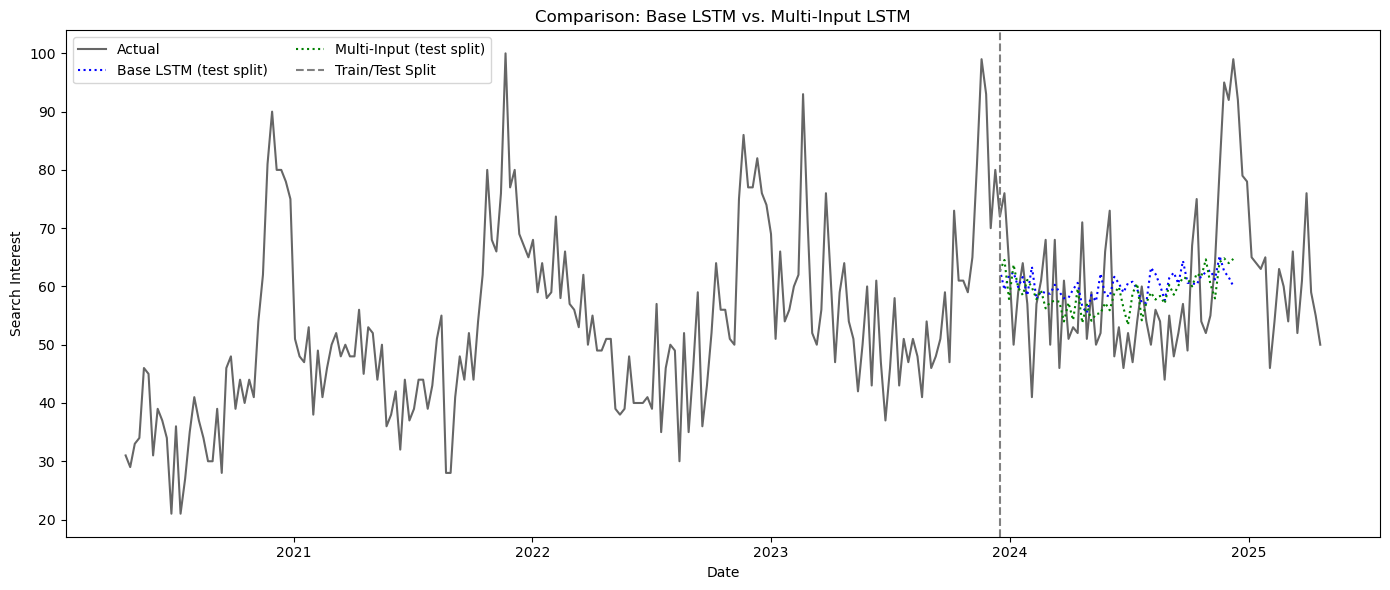

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# --- PARAMETERS -------------------------------------------------------------
look_back = 16     # number of past weeks to use as input
n_future  = 52     # number of weeks to predict

# --- HELPERS ---------------------------------------------------------------
def create_multistep_sequences(X, y, look_back, n_future):
    """
    Build arrays of shape (samples, look_back, features) and (samples, n_future)
    """
    Xs, ys = [], []
    for i in range(len(X) - look_back - n_future + 1):
        Xs.append(X[i : i + look_back])
        # ravel so that y has shape (n_future,)
        ys.append(y[i + look_back : i + look_back + n_future].ravel())
    return np.array(Xs), np.array(ys)

# --- 1) LOAD & MERGE DATA ---------------------------------------------------
# trends data
trends = pd.read_csv('505_trend.csv', skiprows=1, header=None,
                     names=['date','num_search'])
trends['date'] = pd.to_datetime(trends['date'], errors='coerce')
trends = trends.dropna(subset=['date']).sort_values('date')

# sentiment data
df = pd.read_csv('data_sentiment_merged_v3.csv', parse_dates=['date'])
df_505 = df[df['product_name'].str.contains('505', case=False, na=False)]

# weekly aggregation (Sunday-ending)
weekly_sent = (
    df_505
    .set_index('date')
    .resample('W-SUN')
    .agg({
        'avg_sentiment':'mean',
        'avg_8_sentiments':'mean',
        'avg_15_sentiments':'mean',
        'avg_30_sentiments':'mean'
    })
    .reset_index()
)

# align date ranges & merge
start_date, end_date = trends['date'].min(), trends['date'].max()
weekly_sent = weekly_sent[
    (weekly_sent['date'] >= start_date) & 
    (weekly_sent['date'] <= end_date)
]

data = (
    pd.merge(trends, weekly_sent, on='date', how='outer')
      .sort_values('date')
      .ffill()
      .bfill()
      .reset_index(drop=True)
)

# --- 2) SCALE & BUILD SEQUENCES ---------------------------------------------
# Raw arrays
num_raw  = data[['num_search']].values            # shape (T,1)
sent_raw = data[['avg_sentiment','avg_8_sentiments',
                 'avg_15_sentiments','avg_30_sentiments']].values  # (T,4)

# Fit scalers
scaler_num  = MinMaxScaler().fit(num_raw)
scaler_sent = MinMaxScaler().fit(sent_raw)

# Transform
num_scaled  = scaler_num.transform(num_raw)
sent_scaled = scaler_sent.transform(sent_raw)

# Build sequences
X_num_seq, y_seq      = create_multistep_sequences(num_scaled, num_scaled, look_back, n_future)
X_sent_seq, _         = create_multistep_sequences(sent_scaled, num_scaled, look_back, n_future)

# Train/test split (80/20)
split = int(0.90 * len(X_num_seq))
X1_tr, X1_te = X_num_seq[:split],  X_num_seq[split:]
X2_tr, X2_te = X_sent_seq[:split], X_sent_seq[split:]
y_tr,  y_te  = y_seq[:split],      y_seq[split:]

# --- CALLBACKS --------------------------------------------------------------
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop  = EarlyStopping( monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# --- 3) BASE LSTM MODEL -----------------------------------------------------
base_model = Sequential([
    Input((look_back, 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(n_future)   # output a vector of length n_future
])
base_model.compile(optimizer='adam', loss='mse')
base_model.fit(
    X1_tr, y_tr,
    validation_data=(X1_te, y_te),
    epochs=50, batch_size=16,
    callbacks=[lr_schedule, early_stop],
    verbose=1
)

# --- 4) MULTI‐INPUT LSTM MODEL ----------------------------------------------
inp_search = Input(shape=(look_back, 1), name='search_input')
inp_sent   = Input(shape=(look_back, 4), name='sent_input')
merged     = Concatenate(axis=-1)([inp_search, inp_sent])

x = LSTM(64, return_sequences=True)(merged)
x = Dropout(0.2)(x)
x = LSTM(32)(x)
x = Dropout(0.1)(x)
out = Dense(n_future)(x)

mi_model = Model([inp_search, inp_sent], out)
mi_model.compile(optimizer='adam', loss='mse')
mi_model.fit(
    [X1_tr, X2_tr], y_tr,
    validation_data=([X1_te, X2_te], y_te),
    epochs=50, batch_size=16,
    callbacks=[lr_schedule, early_stop],
    verbose=1
)

# --- 5) FULL-DATA FORECAST → CSV & PLOT --------------------------------------
# Last windows
last_num_window  = num_scaled[-look_back:].reshape(1, look_back, 1)
last_sent_window = sent_scaled[-look_back:].reshape(1, look_back, 4)

# Predict
base_forecast_scaled = base_model.predict(last_num_window).ravel()
mi_forecast_scaled   = mi_model.predict([last_num_window, last_sent_window]).ravel()

# Inverse‐scale
base_forecast = scaler_num.inverse_transform(base_forecast_scaled.reshape(-1,1)).ravel()
mi_forecast   = scaler_num.inverse_transform(mi_forecast_scaled.reshape(-1,1)).ravel()

# Future dates
future_dates = [
    data['date'].iloc[-1] + datetime.timedelta(weeks=i)
    for i in range(1, n_future+1)
]

# Save CSV
forecast_df = pd.DataFrame({
    'date':                       future_dates,
    'Base_LSTM_Prediction':       base_forecast,
    'MultiInput_LSTM_Prediction': mi_forecast
})
forecast_df.to_csv('direct_multistep_forecast.csv', index=False)
print("✅ Full‐data direct multi‐step forecast saved to 'direct_multistep_forecast.csv'")

# Plot historical + full‐data forecast
historical_actual = scaler_num.inverse_transform(num_scaled).ravel()

plt.figure(figsize=(14,6))
plt.plot(data['date'], historical_actual, 'k-', label='Actual (Historical)')
plt.plot(future_dates, base_forecast,  'b--', label='Base LSTM Forecast')
plt.plot(future_dates, mi_forecast,    'g-',  label='Multi-Input LSTM Forecast')
plt.axvline(x=future_dates[0], color='red', linestyle='--', label='End of data')
plt.xlabel('Date')
plt.ylabel('Search Interest')
plt.title('Direct Multi-Step Forecast: Next 1 Year')
plt.legend()
plt.tight_layout()
plt.show()

# --- 6) TEST‐SPLIT FORECAST & EVALUATION -------------------------------------
# Predict on test split
base_test_scaled = base_model.predict(X1_te)
mi_test_scaled   = mi_model.predict([X1_te, X2_te])
actual_test      = scaler_num.inverse_transform(y_te)

# Inverse‐scale predictions
base_test_pred = scaler_num.inverse_transform(base_test_scaled)
mi_test_pred   = scaler_num.inverse_transform(mi_test_scaled)

# RMSE
base_rmse = sqrt(mean_squared_error(actual_test, base_test_pred))
mi_rmse   = sqrt(mean_squared_error(actual_test, mi_test_pred))
print(f"Base LSTM Test RMSE:       {base_rmse:.4f}")
print(f"Multi‐Input LSTM Test RMSE: {mi_rmse:.4f}")

# First‐sample test forecast DataFrame + CSV
test_dates = data['date'].iloc[ split + look_back : split + look_back + n_future ]
test_forecast_df = pd.DataFrame({
    'date':                   test_dates,
    'Actual (Test)':          actual_test[0],
    'Base LSTM Prediction':   base_test_pred[0],
    'Multi-Input Prediction': mi_test_pred[0],
})
test_forecast_df.to_csv('test_split_forecast_sample1.csv', index=False)
print("✅ Test‐split forecast (first sample) saved to 'test_split_forecast_sample1.csv'")

# --- 7) TRAIN‐SPLIT LAST‐WINDOW FORECAST -------------------------------------
# Forecast from the final training window
last_tr_num  = X1_tr[-1].reshape(1, look_back, 1)
last_tr_sent = X2_tr[-1].reshape(1, look_back, 4)

tr_base_scaled = base_model.predict(last_tr_num).ravel()
tr_mi_scaled   = mi_model.predict([last_tr_num, last_tr_sent]).ravel()

tr_base_pred = scaler_num.inverse_transform(tr_base_scaled.reshape(-1,1)).ravel()
tr_mi_pred   = scaler_num.inverse_transform(tr_mi_scaled.reshape(-1,1)).ravel()

# Dates for train‐window forecast
train_end_date    = data['date'].iloc[ split + look_back - 1 ]
tr_forecast_dates = [
    train_end_date + datetime.timedelta(weeks=i)
    for i in range(1, n_future+1)
]

# --- 8) CONTINUOUS COMPARISON PLOT ------------------------------------------
boundary_date = test_forecast_df['date'].iloc[0]
data_end_date = data['date'].iloc[-1]

plt.figure(figsize=(14,6))
# actual history
plt.plot(data['date'], historical_actual, 'k-', alpha=0.6, label='Actual')
# train‐window forecasts
# plt.plot(tr_forecast_dates, tr_base_pred,  'b--', label='Base LSTM (train-window)')
# plt.plot(tr_forecast_dates, tr_mi_pred,    'g--', label='Multi-Input (train-window)')
# test‐split forecasts
plt.plot(test_forecast_df['date'], test_forecast_df['Base LSTM Prediction'],   'b:', label='Base LSTM (test split)')
plt.plot(test_forecast_df['date'], test_forecast_df['Multi-Input Prediction'], 'g:', label='Multi-Input (test split)')
# split lines
plt.axvline(x=boundary_date, color='gray', linestyle='--', label='Train/Test Split')
# plt.axvline(x=data_end_date,  color='red',  linestyle='--', label='End of data / full‐forecast start')
plt.xlabel('Date')
plt.ylabel('Search Interest')
plt.title('Comparison: Base LSTM vs. Multi-Input LSTM')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
